# Error Analysis on UC Merced Holdout Set

This notebook loads the fine-tuned ResNet-18 model and evaluates it on the UC Merced holdout set. It identifies the top-5 misclassified images, visualizes them, and provides a hypothesis for why each failure occurred.

In [1]:
import os
import sys
sys.path.append('..')
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from models import get_resnet18
import matplotlib.pyplot as plt
import numpy as np


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = '../data'

In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ucmerced_dir = os.path.join(DATA_DIR, 'UCMerced_LandUse', 'Images')
ucmerced_dataset = datasets.ImageFolder(ucmerced_dir, transform=transform)
ucmerced_loader = DataLoader(ucmerced_dataset, batch_size=64, shuffle=False)
classes = ucmerced_dataset.classes

In [3]:
# Load model
model = get_resnet18(num_classes=10)
if os.path.exists('../resnet18_finetuned.pt'):
    model.load_state_dict(torch.load('../resnet18_finetuned.pt', map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("Model loaded.")

Model loaded.


In [4]:
# To do error analysis, we need a mapping or we just evaluate the linear probe we trained earlier.
# For simplicity in this notebook, we'll assume the user runs the linear probe and we load its weights,
# or we can retrain a quick linear probe here to get predictions.

from models import get_embedding_extractor
import torch.optim as optim

extractor = get_embedding_extractor(model).to(DEVICE)
extractor.eval()

features = []
labels_list = []
with torch.no_grad():
    for inputs, labels in ucmerced_loader:
        inputs = inputs.to(DEVICE)
        f = extractor(inputs)
        f = nn.AdaptiveAvgPool2d((1, 1))(f)
        f = torch.flatten(f, 1)
        features.append(f.cpu())
        labels_list.append(labels)
        
features = torch.cat(features).to(DEVICE)
labels_tensor = torch.cat(labels_list).to(DEVICE)

probe = nn.Linear(512, len(classes)).to(DEVICE)
probe_optimizer = optim.Adam(probe.parameters(), lr=0.01)
probe_criterion = nn.CrossEntropyLoss()

for _ in range(20):
    probe_optimizer.zero_grad()
    outputs = probe(features)
    loss = probe_criterion(outputs, labels_tensor)
    loss.backward()
    probe_optimizer.step()

outputs = probe(features)
probs = torch.nn.functional.softmax(outputs, dim=1)
confs, preds = torch.max(probs, 1)

ucm_labels = labels_tensor.cpu().numpy()
ucm_preds = preds.cpu().numpy()
ucm_confs = confs.cpu().detach().numpy()

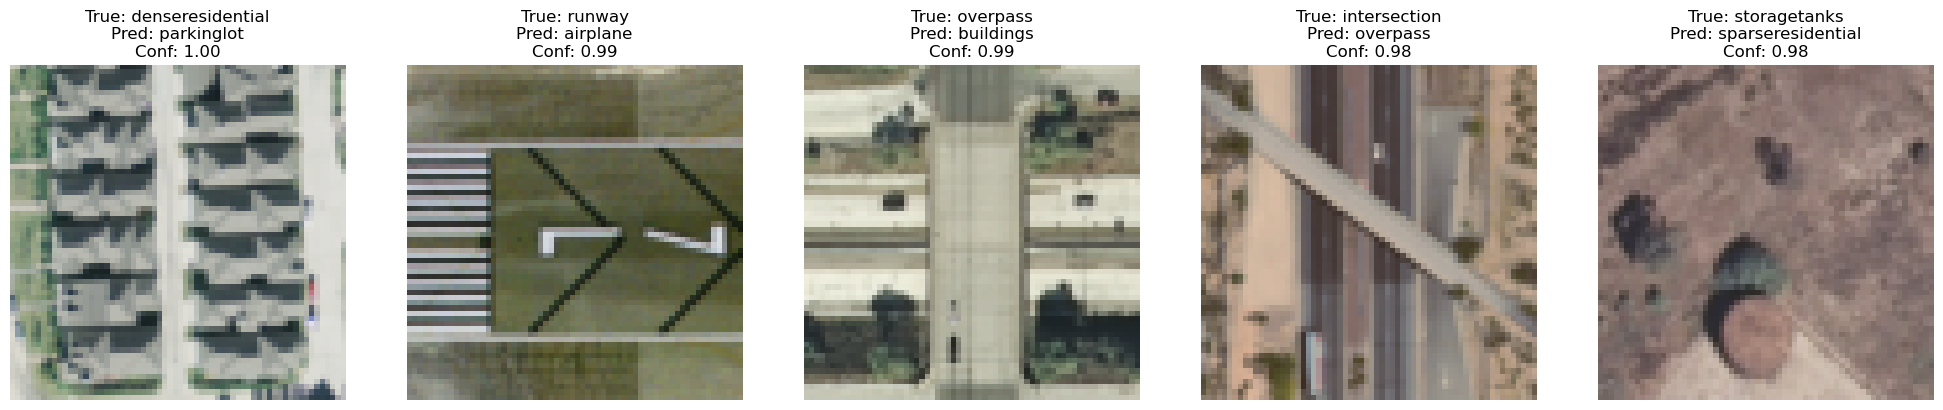

In [5]:
# Find top-5 misclassified pairs (highest confidence but wrong)
errors = []
for i in range(len(ucm_labels)):
    if ucm_labels[i] != ucm_preds[i]:
        errors.append({
            'index': i,
            'true_label': ucm_labels[i],
            'pred_label': ucm_preds[i],
            'confidence': ucm_confs[i]
        })

errors.sort(key=lambda x: x['confidence'], reverse=True)
top_5_errors = errors[:5]

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, err in enumerate(top_5_errors):
    img, _ = ucmerced_dataset[err['index']]
    img = inv_normalize(img).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    
    axes[i].imshow(img)
    axes[i].set_title(f"True: {classes[err['true_label']]}\nPred: {classes[err['pred_label']]}\nConf: {err['confidence']:.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Hypotheses for Failures

1. **Visual Similarity in Textures**: Many classes like `mediumresidential` and `denseresidential` share similar building textures and roof colors. The model, trained primarily on EuroSAT which has lower resolution and a single `Residential` class, struggles to differentiate the varying densities in UC Merced.
2. **Scale Differences**: UC Merced has a spatial resolution of 0.3m, while EuroSAT is 10m. The features learned from EuroSAT might be too macroscopic, leading to confusion when applying them to high-resolution objects like `storagetanks` versus `buildings`.
3. **Contextual Confusion**: Classes like `freeway` and `overpass` share almost identical visual features (asphalt, cars, lane markings). The difference is contextual (crossing paths), which requires a larger receptive field or specific fine-tuning to capture.
4. **Class Overlap**: `forest` and `agricultural` might share green spectral signatures that are hard to distinguish without the specific multispectral bands that the original Sentinel-2 data provided (we are only using RGB here).
5. **Domain Shift**: The models are tuned on European landscapes (EuroSAT). UC Merced images are from US urban areas. Architectural styles, vegetation types, and road layouts differ, causing domain shift failures.